 # Mixl1 Chimera Analysis -- Index Hopping Correction
 
 #### Mai-Linh Ton
 #### 17 May 2020


In [1]:
library(DropletUtils)
library(ggplot2)
library(cowplot)
library(Matrix)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tap

In [4]:
##==Read in all molecule_info.h5 files from Mixl1 cellranger files==##

wd <- paste0("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/SLX19260_Mixl1_SIGA",LETTERS[1:6],"5/outs/")

molecule_h5 <- paste0(wd, "molecule_info.h5")

In [12]:
##==Run the 6 samples in one instance of swappedDrops (since they're from the same sequencing batch)==##
unswapped = swappedDrops(molecule_h5, get.swapped = TRUE)

#=Calculate the ratio of swapped UMIs=#
ratios = sapply(1:length(unswapped$cleaned), function(i){
  sum(unswapped$swapped[[i]])/(sum(unswapped$cleaned[[i]]) + sum(unswapped$swapped[[i]]))
})

names(ratios) = 1:length(molecule_h5)

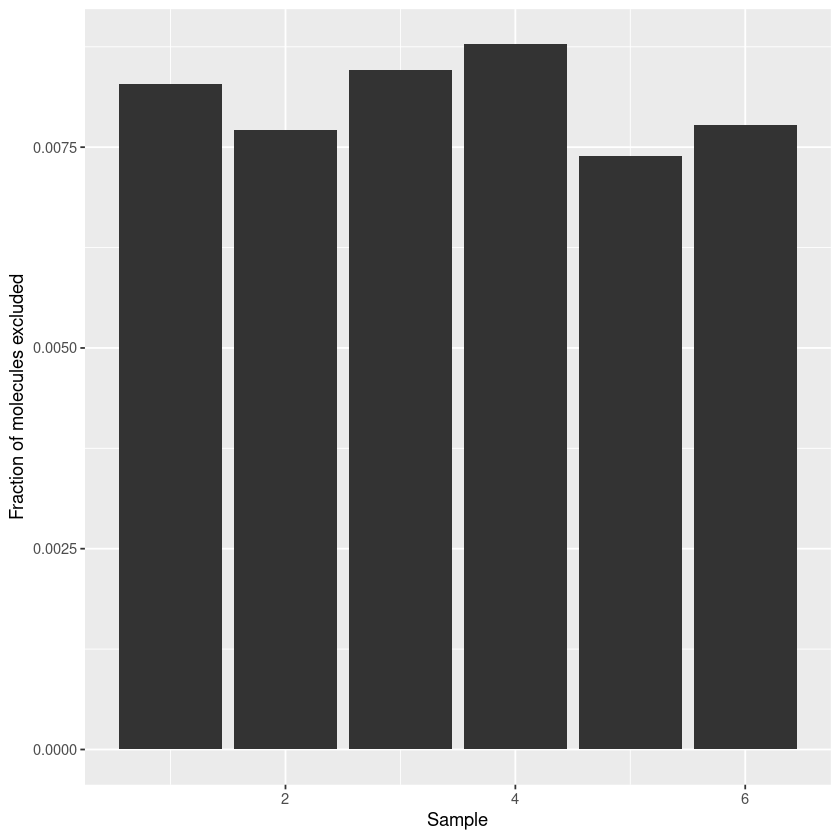

In [14]:
##==Visualize Fraction Swapped per Sample===##

ggplot(data.frame(ratios = ratios, sample = 1:6), aes(x = sample, y = ratios)) + geom_bar(stat = "identity", fill = "grey20") + labs(x = "Sample", y = "Fraction of molecules excluded")

### As things pass visual inspection, write the output files

In [18]:
##==Write the Output Directories==##

wd_out <- paste0("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/1_indexCorrection/SIGA",LETTERS[1:6],"5/")

#=Each sample will have 3 files (matrix, barcodes, and gene list)=#

out_loc <- paste0(wd_out, "matrix.mtx")
bc_loc <- paste0(wd_out, "barcodes.tsv")
gene_loc <- paste0(wd_out, "genes.tsv")

In [17]:
#write the output files
for(i in 1:length(molecule_h5)){
  null_holder = writeMM(unswapped$cleaned[[i]], file = out_loc[i])
  write.table(colnames(unswapped$cleaned[[i]]), file = bc_loc[i], col.names = FALSE, row.names = FALSE, quote = FALSE)
  write.table(rownames(unswapped$cleaned[[i]]), file = gene_loc[i], col.names = FALSE, row.names = FALSE, quote = FALSE)
}

In [16]:
sessionInfo()

R version 3.6.1 (2019-07-05)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Scientific Linux 7.7 (Nitrogen)

Matrix products: default
BLAS:   /usr/local/software/spack/spack-0.11.2/opt/spack/linux-rhel7-x86_64/gcc-5.4.0/r-3.6.1-zrytncqvsnw5h4dl6t6njefj7otl4bg4/rlib/R/lib/libRblas.so
LAPACK: /usr/local/software/spack/spack-0.11.2/opt/spack/linux-rhel7-x86_64/gcc-5.4.0/r-3.6.1-zrytncqvsnw5h4dl6t6njefj7otl4bg4/rlib/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] Matrix_1.2-17               cowplot_1.0.